# Q-Learning con Variable Green Durations

s = (nvehicles, twaiting, lqueue, rarrival). Acciones: 12 duraciones de verde (5-60s).
Recompensa: multi-objetivo paper Electronics 2025 (sin clipping).

Configuracion:
- 5000 epocas, num_seconds=100000, delta_time=5
- Epsilon: 0.5 -> 0.05 con decay 0.9995 (por episodio)
- Sin clipping de recompensa
- Discretizador: 6/6/4/3 bins (288 estados x 12 acciones = 3456 total)
- Experience Replay: buffer=2000, batch=64, update_freq=4
- QLAgentConVisitas: tracking de visitas + early stopping por cobertura
- Guarda ultimo modelo

In [1]:
import os
os.environ["LIBSUMO_AS_TRACI"] = "1"

In [2]:
import traci

# Limpiar conexiones zombie de ejecuciones anteriores
try:
    traci.close()
except:
    pass

Using libsumo as traci as requested by environment variable.


In [3]:
import argparse
import pandas as pd
import pickle
import sys
import numpy as np
import gymnasium as gym
from sumo_rl import SumoEnvironment
from sumo_rl.agents import QLAgent
from sumo_rl.exploration import EpsilonGreedy
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
if 'SUMO_HOME' not in os.environ:
    os.environ['SUMO_HOME'] = '/usr/share/sumo'
tools = os.path.join(os.environ['SUMO_HOME'], 'tools')
sys.path.append(tools)

In [5]:
NET = os.path.join("..", "Simple_Intersection.net.xml")
ROU = os.path.join("..", "Distribuciones", "loja_intersection_weibull.rou.xml")
OUT_FOLDER = "resultados"

os.makedirs(OUT_FOLDER, exist_ok=True)

print(f"NET existe: {os.path.exists(NET)}")
print(f"ROU existe: {os.path.exists(ROU)}")

NET existe: True
ROU existe: True


In [6]:
# Reward: paper 2025 (4 componentes)
def recompensa_paper_2025(ts):
    """
    Funcion de recompensa multi-objetivo basada en:
    "Comparative Evaluation of Fuzzy Logic and Q-Learning for Adaptive Urban
    Traffic Signal Control" (Electronics 2025, 14, 2759)

    Componentes:
    1. Penalizacion por tiempo de espera promedio (-2.0 * waiting_time)
    2. Recompensa por throughput (+1.5 * vehicles_departed)
    3. Recompensa por mejora en espera (+3.0 * improvement)
    4. Penalizacion por congestion severa (-100.0 si waiting>9s AND queue>61)
    """
    if not hasattr(recompensa_paper_2025, '_prev'):
        recompensa_paper_2025._prev = {'waiting': 0.0, 'veh_ids': set()}

    prev = recompensa_paper_2025._prev

    ids = ts.sumo.vehicle.getIDList()
    waiting_time = np.mean([ts.sumo.vehicle.getWaitingTime(v) for v in ids]) if len(ids) > 0 else 0.0
    veh_ids_actuales = set(v for lane in ts.lanes for v in ts.sumo.lane.getLastStepVehicleIDs(lane))
    throughput = len(prev['veh_ids'] - veh_ids_actuales)
    queue = ts.get_total_queued()

    component_1 = -2.0 * waiting_time
    component_2 = 1.5 * throughput
    component_3 = 3.0 * (prev['waiting'] - waiting_time)
    component_4 = -100.0 if (waiting_time > 9 and queue > 61) else 0.0

    total_reward = component_1 + component_2 + component_3 + component_4

    recompensa_paper_2025._prev = {'waiting': waiting_time, 'veh_ids': veh_ids_actuales}
    return total_reward


def reset_recompensa():
    """Resetear estado interno de la funcion de recompensa."""
    if hasattr(recompensa_paper_2025, '_prev'):
        recompensa_paper_2025._prev = {'waiting': 0.0, 'veh_ids': set()}


# ========== VARIABLE GREEN WRAPPER ==========
class VariableGreenWrapper(gym.Wrapper):
    """Seleccion de duracion de verde (5-60s en pasos de 5s)."""
    DURACIONES = list(range(5, 65, 5))  # 12 acciones: 5-60s

    def __init__(self, env, delta_time=5):
        super().__init__(env)
        self.delta_time = delta_time
        self.action_space = gym.spaces.Discrete(len(self.DURACIONES))
        self._fase_actual = 0

    def step(self, action_idx):
        duracion = self.DURACIONES[action_idx]
        n_pasos = duracion // self.delta_time
        reward_acumulado = 0.0
        terminated = truncated = False
        info = {}
        for _ in range(n_pasos):
            obs, reward, terminated, truncated, info = self.env.step(self._fase_actual)
            reward_acumulado += reward
            if terminated or truncated:
                break
            if self.env.unwrapped.sumo.simulation.getMinExpectedNumber() == 0:
                break
        self._fase_actual = 1 - self._fase_actual
        return obs, reward_acumulado, terminated, truncated, info

    def reset(self, **kwargs):
        self._fase_actual = 0
        return self.env.reset(**kwargs)


# ========== REPLAY BUFFER ==========
class ReplayBuffer:
    """
    Buffer de experiencias para Q-learning con replay.
    buffer_size=2000, batch_size=64.
    """
    def __init__(self, buffer_size=2000):
        self.buffer_size = buffer_size
        self.buffer = []
        self.position = 0
        self.total_pushes = 0
        self.total_samples = 0

    def push(self, state, action, reward, next_state, done):
        experience = (state, action, reward, next_state, done)
        if len(self.buffer) < self.buffer_size:
            self.buffer.append(experience)
        else:
            self.buffer[self.position] = experience
        self.position = (self.position + 1) % self.buffer_size
        self.total_pushes += 1

    def sample(self, batch_size=64):
        if len(self.buffer) < batch_size:
            return self.buffer
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)
        self.total_samples += batch_size
        return [self.buffer[i] for i in indices]

    def __len__(self):
        return len(self.buffer)

    def clear(self):
        self.buffer = []
        self.position = 0
        self.total_pushes = 0
        self.total_samples = 0

    def get_stats(self):
        if len(self.buffer) == 0:
            return {'size': 0, 'capacity': self.buffer_size, 'fill_ratio': 0.0,
                    'avg_reward': 0.0, 'total_pushes': self.total_pushes, 'total_samples': self.total_samples}
        rewards = [exp[2] for exp in self.buffer]
        return {
            'size': len(self.buffer), 'capacity': self.buffer_size,
            'fill_ratio': len(self.buffer) / self.buffer_size,
            'avg_reward': np.mean(rewards), 'min_reward': np.min(rewards), 'max_reward': np.max(rewards),
            'total_pushes': self.total_pushes, 'total_samples': self.total_samples
        }


# ========== Q-LAGENT WITH REPLAY ==========
class QLAgentWithReplay(QLAgent):
    """QLAgent extendido con experience replay."""
    def __init__(self, starting_state, state_space, action_space,
                 alpha, gamma, exploration_strategy,
                 replay_buffer, batch_size=64, update_freq=4):
        super().__init__(starting_state, state_space, action_space,
                        alpha, gamma, exploration_strategy)
        self.replay_buffer = replay_buffer
        self.batch_size = batch_size
        self.update_freq = update_freq
        self.step_count = 0

    def act(self):
        """Initialize state in Q-table if missing, then choose action."""
        state_tuple = tuple(self.state) if hasattr(self.state, '__iter__') else self.state
        if state_tuple not in self.q_table:
            self.q_table[state_tuple] = [0.0] * self.action_space.n
        return super().act()

    def learn_with_replay(self, next_state, reward, done):
        self.replay_buffer.push(self.state, self.action, reward, next_state, done)
        self.state = next_state
        self.step_count += 1
        if len(self.replay_buffer) >= self.batch_size and self.step_count % self.update_freq == 0:
            batch = self.replay_buffer.sample(self.batch_size)
            for state, action, reward, next_state, done in batch:
                self._update_q(state, action, reward, next_state, done)

    def _update_q(self, state, action, reward, next_state, done):
        s = tuple(state) if hasattr(state, '__iter__') else state
        ns = tuple(next_state) if hasattr(next_state, '__iter__') else next_state
        if s not in self.q_table:
            self.q_table[s] = [0.0] * self.action_space.n
        if ns not in self.q_table:
            self.q_table[ns] = [0.0] * self.action_space.n
        target = reward if done else reward + self.gamma * max(self.q_table[ns])
        self.q_table[s][action] += self.alpha * (target - self.q_table[s][action])


# ========== Q-LAGENT CON VISITAS ==========
class QLAgentConVisitas(QLAgentWithReplay):
    """QLAgent con conteo de visitas por estado."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.visitas = {}

    def act(self):
        estado = tuple(self.state) if hasattr(self.state, '__iter__') else self.state
        self.visitas[estado] = self.visitas.get(estado, 0) + 1
        if estado not in self.q_table:
            self.q_table[estado] = [0.0] * self.action_space.n
        return super().act()


In [7]:
# Cargar bin edges calibrados
_edges = np.load("../Simulaciones_tiempos_fijos/resultados/bin_edges_calibrados.npz")
EDGES_NVEHICULOS = _edges["nvehiculos"]
EDGES_WAITING    = _edges["waiting"]
EDGES_QUEUE      = _edges["queue"]
EDGES_ARRIVAL    = _edges["arrival"]


class TrafficStateWrapper(gym.Wrapper):
    """Estado discreto: (nvehiculos, twaiting, lqueue, rarrival) con edges calibrados."""
    observation_space = gym.spaces.MultiDiscrete([6, 6, 4, 3])

    def _compute_state(self):
        ids = self.env.unwrapped.sumo.vehicle.getIDList()
        n_vehiculos = len(ids)
        waiting = np.mean([self.env.unwrapped.sumo.vehicle.getWaitingTime(v) for v in ids]) if n_vehiculos > 0 else 0.0
        queue = self.env.unwrapped.traffic_signals[self.env.unwrapped.ts_ids[0]].get_total_queued()

        if not hasattr(self, '_ventana_llegadas'):
            self._ventana_llegadas = []
        arrival_step = self.env.unwrapped.sumo.simulation.getDepartedNumber()
        self._ventana_llegadas.append(arrival_step)
        if len(self._ventana_llegadas) > 6:
            self._ventana_llegadas.pop(0)
        arrival = sum(self._ventana_llegadas)

        bin_n = int(np.digitize(n_vehiculos, EDGES_NVEHICULOS))
        bin_w = int(np.digitize(waiting, EDGES_WAITING))
        bin_q = int(np.digitize(queue, EDGES_QUEUE))
        bin_a = int(np.digitize(arrival, EDGES_ARRIVAL))

        return (bin_n, bin_w, bin_q, bin_a)

    def reset(self, **kwargs):
        self._ventana_llegadas = []
        obs, info = self.env.reset(**kwargs)
        return self._compute_state(), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._compute_state(), reward, terminated, truncated, info


In [8]:
def get_args():
    prs = argparse.ArgumentParser(formatter_class=argparse.ArgumentDefaultsHelpFormatter)
    prs.add_argument("-route", dest="route", type=str, default=ROU)
    prs.add_argument("-net", dest="net", type=str, default=NET)
    prs.add_argument("-a", dest="alpha", type=float, default=0.1)
    prs.add_argument("-g", dest="gamma", type=float, default=0.95)
    prs.add_argument("-gui", action="store_true", default=False)
    prs.add_argument("-r", dest="reward", type=str, default='paper_2025')
    prs.add_argument("-runs", dest="runs", type=int, default=1)
    prs.add_argument("-episodes", dest="episodes", type=int, default=5000)
    prs.add_argument("-num_seconds", dest="num_seconds", type=int, default=100000)
    prs.add_argument("-min_epsilon", dest="min_epsilon", type=float, default=0.05)
    prs.add_argument("-initial_epsilon", dest="initial_epsilon", type=float, default=0.5)
    prs.add_argument("-decay", dest="decay", type=float, default=0.9995)
    return prs.parse_args(args=[])


In [9]:
if __name__ == '__main__':
    if 'args' not in dir():
        args = get_args()

    exploracion = EpsilonGreedy(
        initial_epsilon=args.initial_epsilon,
        min_epsilon=args.min_epsilon,
        decay=1.0  # sin decay interno, solo el loop controla por episodio
    )

    replay_buffer = ReplayBuffer(buffer_size=2000)

    import sys as _sys
    import os as _os
    _old_stderr = _sys.stderr
    _sys.stderr = open(_os.devnull, 'w')

    env_temp = SumoEnvironment(
        net_file=args.net,
        route_file=args.route,
        out_csv_name="temp",
        single_agent=True,
        delta_time=5,
        yellow_time=3,
        min_green=5,
        reward_fn=recompensa_paper_2025,
        additional_sumo_cmd="-W --no-step-log"
    )

    _sys.stderr = _old_stderr

    env_temp = VariableGreenWrapper(env_temp, delta_time=5)
    env_temp = TrafficStateWrapper(env_temp)
    obs_inicial, _ = env_temp.reset()

    agente = QLAgentConVisitas(
        starting_state=obs_inicial,
        state_space=env_temp.observation_space,
        action_space=env_temp.action_space,
        alpha=args.alpha,
        gamma=args.gamma,
        exploration_strategy=exploracion,
        replay_buffer=replay_buffer,
        batch_size=64,
        update_freq=4
    )

    env_temp.close()

    historial_recompensas = []
    cobertura_historial = []

    def cobertura_estabilizada(historial, ventana=5):
        return len(historial) >= ventana and historial[-1] <= historial[-ventana]

    print("Entrenamiento Q-Learning (12 duraciones de verde, reward paper 2025)...")
    for run in range(1, args.runs + 1):
        for episode in range(1, args.episodes + 1):
            reset_recompensa()

            _old_stderr2 = _sys.stderr
            _sys.stderr = open(_os.devnull, 'w')

            env = SumoEnvironment(
                net_file=args.net,
                route_file=args.route,
                out_csv_name="temp",
                single_agent=True,
                use_gui=args.gui,
                num_seconds=args.num_seconds,
                delta_time=5,
                yellow_time=3,
                min_green=5,
                reward_fn=recompensa_paper_2025,
                time_to_teleport=-1,
                additional_sumo_cmd="-W --no-step-log"
            )

            _sys.stderr = _old_stderr2

            env = VariableGreenWrapper(env, delta_time=5)
            env = TrafficStateWrapper(env)
            obs, _ = env.reset()
            try:
                agente.state = obs
                done = False
                recompensa_episodio = 0

                tiempo_final = 0
                while not done:
                    accion = agente.act()
                    next_obs, reward, terminated, truncated, info = env.step(accion)

                    agente.learn_with_replay(next_state=next_obs, reward=reward, done=terminated)
                    recompensa_episodio += reward

                    if env.unwrapped.sumo.simulation.getMinExpectedNumber() == 0:
                        tiempo_final = env.unwrapped.sim_step
                        break

                    done = terminated or truncated

                historial_recompensas.append(recompensa_episodio)

            finally:
                env.close()

            exploracion.epsilon = max(exploracion.epsilon * args.decay, args.min_epsilon)

            if episode % 100 == 0:
                cobertura = len(agente.q_table) / (6 * 6 * 4 * 3)
                cobertura_historial.append(cobertura)
                print(f"  Ep {episode:03d} | Rec: {recompensa_episodio:10.2f} | Epsilon: {exploracion.epsilon:.3f} | Vaciado: {tiempo_final:.0f}s | Cobertura: {cobertura:.1%}")
            else:
                print(f"  Ep {episode:03d} | Rec: {recompensa_episodio:10.2f} | Epsilon: {exploracion.epsilon:.3f} | Vaciado: {tiempo_final:.0f}s")

            if cobertura_estabilizada(cobertura_historial):
                print(f"Cobertura estabilizada en episodio {episode} - deteniendo entrenamiento")
                break

    with open(os.path.join(OUT_FOLDER, "qlearning.pkl"), 'wb') as f:
        pickle.dump(agente.q_table, f)
    print(f"\nModelo guardado en {os.path.join(OUT_FOLDER, 'qlearning.pkl')}")

    print("\n" + "="*60)
    print("ESTADISTICAS DEL ENTRENAMIENTO")

# Limpiar CSVs temporales de entrenamiento
import glob as _glob
for _f in _glob.glob("temp_*.csv"):
    os.remove(_f)
    print("="*60)
    print(f"Estados en Q-table: {len(agente.q_table)}")
    print(f"Total estados posibles: {6*6*4*3} (bins 6/6/4/3, independiente de las 12 acciones)")
    print(f"Cobertura final: {len(agente.q_table)/(6*6*4*3):.1%}")
    print(f"\nTop 10 estados mas visitados:")
    top_visitados = sorted(agente.visitas.items(), key=lambda x: x[1], reverse=True)[:10]
    for estado, visits in top_visitados:
        print(f"  {estado}: {visits} visitas")

    stats = replay_buffer.get_stats()
    print(f"\nExperience Replay Buffer:")
    print(f"Tamaño actual: {stats['size']} / {stats['capacity']}")
    print(f"Total experiencias: {stats['total_pushes']}")


Entrenamiento Q-Learning (12 duraciones de verde, reward paper 2025)...
  Ep 001 | Rec:  -12991.26 | Epsilon: 0.500 | Vaciado: 3850s
  Ep 002 | Rec:  -13450.20 | Epsilon: 0.500 | Vaciado: 3890s
  Ep 003 | Rec:  -10154.56 | Epsilon: 0.499 | Vaciado: 3770s
  Ep 004 | Rec:   -7427.60 | Epsilon: 0.499 | Vaciado: 3880s
  Ep 005 | Rec:  -14555.26 | Epsilon: 0.499 | Vaciado: 3980s
  Ep 006 | Rec:  -13255.89 | Epsilon: 0.499 | Vaciado: 3945s
  Ep 007 | Rec:   -8693.58 | Epsilon: 0.498 | Vaciado: 3845s
  Ep 008 | Rec:  -14886.47 | Epsilon: 0.498 | Vaciado: 3820s
  Ep 009 | Rec:   -7867.45 | Epsilon: 0.498 | Vaciado: 3800s
  Ep 010 | Rec:  -10224.89 | Epsilon: 0.498 | Vaciado: 3940s
  Ep 011 | Rec:  -10648.90 | Epsilon: 0.497 | Vaciado: 4015s
  Ep 012 | Rec:  -10909.73 | Epsilon: 0.497 | Vaciado: 3790s
  Ep 013 | Rec:   -7743.93 | Epsilon: 0.497 | Vaciado: 3895s
  Ep 014 | Rec:  -11658.22 | Epsilon: 0.497 | Vaciado: 3795s
  Ep 015 | Rec:  -15715.90 | Epsilon: 0.496 | Vaciado: 4160s
  Ep 016 | Re

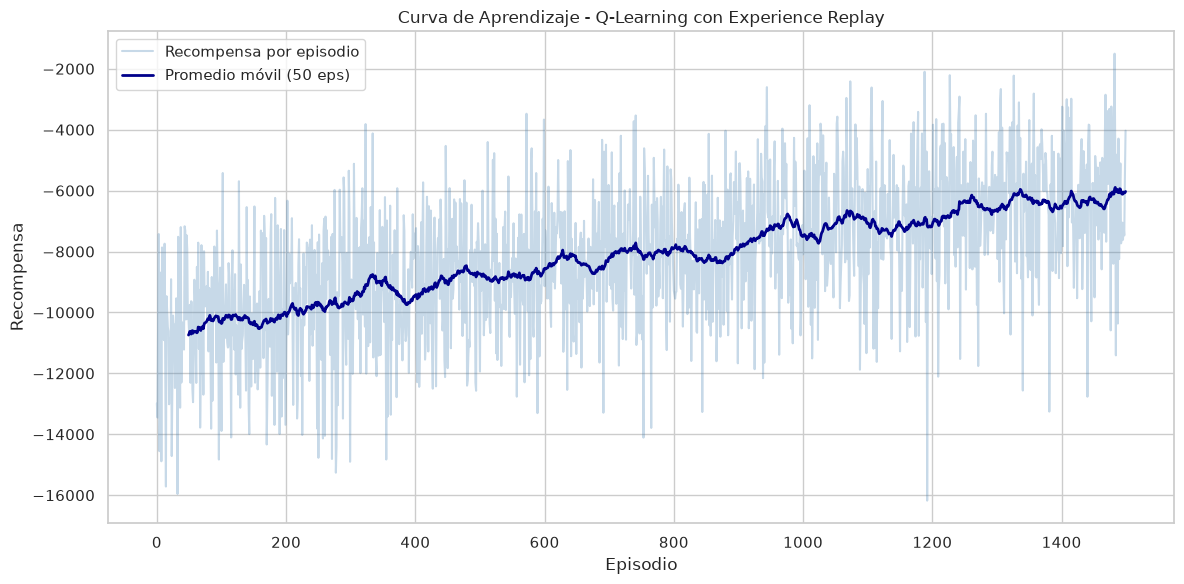

In [10]:
# Curva de Aprendizaje
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
plt.plot(historial_recompensas, alpha=0.3, label="Recompensa por episodio", color="steelblue")

# Promedio móvil
if len(historial_recompensas) >= 50:
    window = 50
    promedio_movil = pd.Series(historial_recompensas).rolling(window=window).mean()
    plt.plot(promedio_movil, label=f"Promedio móvil ({window} eps)", color="darkblue", linewidth=2)

plt.xlabel("Episodio")
plt.ylabel("Recompensa")
plt.title("Curva de Aprendizaje - Q-Learning con Experience Replay")
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
args = get_args()
ruta_modelo = os.path.join(OUT_FOLDER, "qlearning.pkl")

print(f"Cargando modelo: {ruta_modelo}")
with open(ruta_modelo, 'rb') as f:
    q_table_entrenada = pickle.load(f)

print(f"Estados en Q-table: {len(q_table_entrenada)}")

# Configuracion de evaluacion
USAR_FALLBACK = False  # True: estados no vistos -> 30s | False: estados no vistos -> aleatorio

env_eval = SumoEnvironment(
    net_file=args.net,
    route_file=args.route,
    out_csv_name=os.path.join(OUT_FOLDER, "evaluacion_final"),
    single_agent=True,
    use_gui=False,
    num_seconds=args.num_seconds,
    delta_time=5,
    yellow_time=3,
    min_green=5,
    time_to_teleport=-1,
    additional_sumo_cmd=f"-W --no-step-log --tripinfo-output {os.path.join(OUT_FOLDER, 'tripinfo.xml')}"
)

env_eval = VariableGreenWrapper(env_eval, delta_time=5)
env_eval = TrafficStateWrapper(env_eval)

obs, _ = env_eval.reset()
try:

    exploracion_nula = EpsilonGreedy(initial_epsilon=0.0, min_epsilon=0.0, decay=1.0)
    replay_buffer_eval = ReplayBuffer(buffer_size=2000)
    agente_eval = QLAgentConVisitas(
        starting_state=obs,
        state_space=env_eval.observation_space,
        action_space=env_eval.action_space,
        alpha=0.0,
        gamma=args.gamma,
        exploration_strategy=exploracion_nula,
        replay_buffer=replay_buffer_eval,
        batch_size=64,
        update_freq=4
    )
    agente_eval.q_table = q_table_entrenada

    DURACIONES = VariableGreenWrapper.DURACIONES
    N_ACCIONES = len(DURACIONES)

    def elegir_accion(q_table, estado, n_acciones):
        if estado in q_table:
            return int(np.argmax(q_table[estado]))
        if USAR_FALLBACK:
            return n_acciones // 2  # 30s: accion de emergencia
        return int(np.random.randint(n_acciones))  # aleatorio

    modo = "FALLBACK (30s)" if USAR_FALLBACK else "ALEATORIO"
    print(f"Ejecutando evaluacion en modo: {modo}")

    done = False
    datos_recolectados = []

    while not done:
        estado_actual = tuple(agente_eval.state)
        accion = elegir_accion(agente_eval.q_table, estado_actual, N_ACCIONES)
        next_obs, reward, terminated, truncated, info = env_eval.step(accion)

        datos_recolectados.append(info)
        agente_eval.state = next_obs

        if env_eval.unwrapped.sumo.simulation.getMinExpectedNumber() == 0:
            tiempo_final = env_eval.unwrapped.sim_step
            print(f"Evaluacion completada. Red vaciada en {tiempo_final:.1f}s")
            break

        done = terminated or truncated

finally:
    env_eval.close()

df_metricas = pd.DataFrame(datos_recolectados)
ruta_csv = os.path.join(OUT_FOLDER, "metricas.csv")
os.makedirs(OUT_FOLDER, exist_ok=True)
df_metricas.to_csv(ruta_csv, index=False)

print(f"CSV exportado: {ruta_csv}")
print(f"XML generado: {os.path.join(OUT_FOLDER, 'tripinfo.xml')}")

Cargando modelo: resultados/qlearning.pkl
Estados en Q-table: 269
Ejecutando evaluacion en modo: ALEATORIO
Evaluacion completada. Red vaciada en 4065.0s
CSV exportado: resultados/metricas.csv
XML generado: resultados/tripinfo.xml


In [12]:
df_metricas = pd.read_csv(os.path.join(OUT_FOLDER, "metricas.csv"))
print(f"Registros cargados: {len(df_metricas)}")

Registros cargados: 265


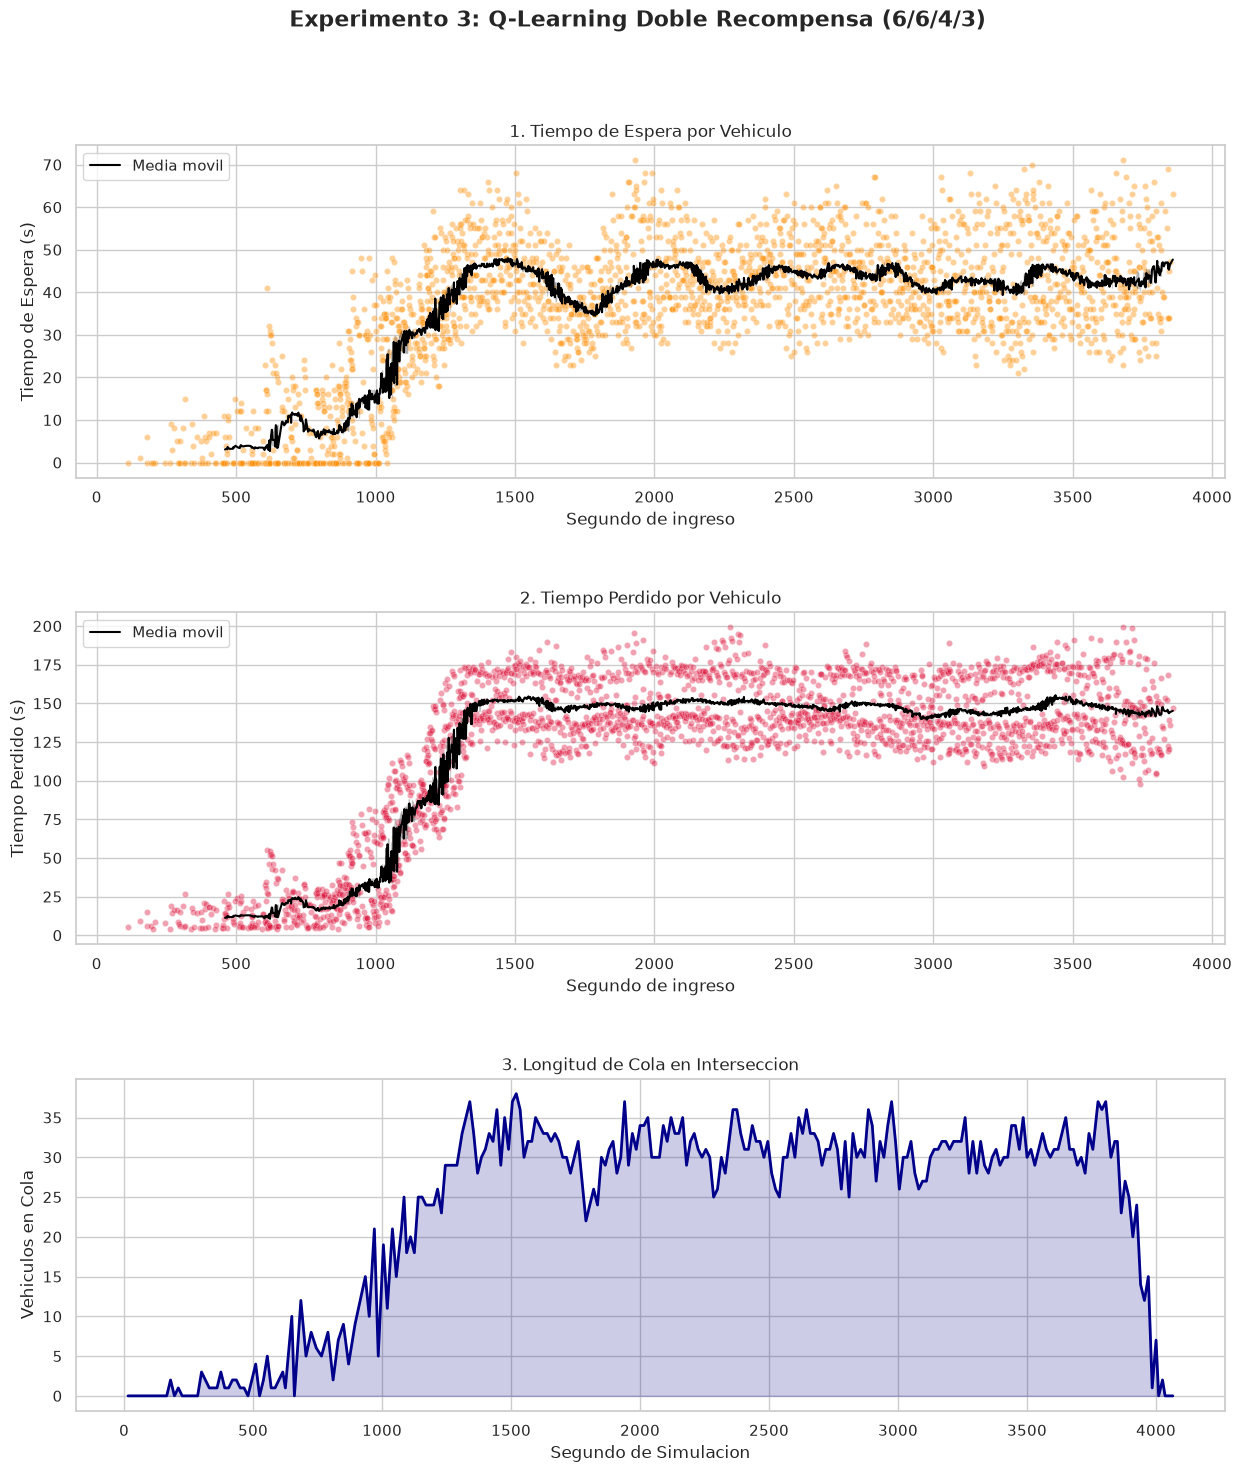

In [13]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

ruta_xml = os.path.join(OUT_FOLDER, "tripinfo.xml")
df_trips = pd.read_xml(ruta_xml)

for col in ['depart', 'waitingTime', 'timeLoss']:
    df_trips[col] = pd.to_numeric(df_trips[col])

fig, axs = plt.subplots(3, 1, figsize=(14, 15))
fig.tight_layout(pad=6.0)
fig.suptitle('Experimento 3: Q-Learning Doble Recompensa (6/6/4/3)', fontsize=16, fontweight='bold', y=1.02)

sns.scatterplot(x=df_trips['depart'], y=df_trips['waitingTime'], alpha=0.4, color='darkorange', s=20, ax=axs[0])
sns.lineplot(x=df_trips['depart'], y=df_trips['waitingTime'].rolling(50).mean(), color='black', label='Media movil', ax=axs[0])
axs[0].set_title("1. Tiempo de Espera por Vehiculo")
axs[0].set_xlabel("Segundo de ingreso")
axs[0].set_ylabel("Tiempo de Espera (s)")
axs[0].legend()

sns.scatterplot(x=df_trips['depart'], y=df_trips['timeLoss'], alpha=0.4, color='crimson', s=20, ax=axs[1])
sns.lineplot(x=df_trips['depart'], y=df_trips['timeLoss'].rolling(50).mean(), color='black', label='Media movil', ax=axs[1])
axs[1].set_title("2. Tiempo Perdido por Vehiculo")
axs[1].set_xlabel("Segundo de ingreso")
axs[1].set_ylabel("Tiempo Perdido (s)")
axs[1].legend()

axs[2].plot(df_metricas['step'], df_metricas['system_total_stopped'], color='darkblue', linewidth=2)
axs[2].fill_between(df_metricas['step'], df_metricas['system_total_stopped'], color='darkblue', alpha=0.2)
axs[2].set_title("3. Longitud de Cola en Interseccion")
axs[2].set_xlabel("Segundo de Simulacion")
axs[2].set_ylabel("Vehiculos en Cola")

plt.show()

In [15]:
for col in ['waitingTime', 'timeLoss', 'routeLength', 'duration']:
    df_trips[col] = pd.to_numeric(df_trips[col])

df_trips['velocidad_kmh'] = (df_trips['routeLength'] / df_trips['duration']) * 3.6

promedio_espera = df_trips['waitingTime'].mean()
maximo_espera = df_trips['waitingTime'].max()
promedio_perdido = df_trips['timeLoss'].mean()
maximo_perdido = df_trips['timeLoss'].max()
velocidad_media = df_trips['velocidad_kmh'].mean()
total_vehiculos = len(df_trips)
cola_promedio = df_metricas['system_total_stopped'].mean()
cola_maxima = df_metricas['system_total_stopped'].max()

print("=" * 50)
print("  METRICAS: Experimento 3 - Q-Learning Doble Recompensa")
print("=" * 50)
print("\n--- Rendimiento General ---")
print(f"Total de vehiculos procesados : {total_vehiculos}")
print(f"Velocidad promedio del sistema: {velocidad_media:.2f} km/h")

print("\n--- Demora Vehicular ---")
print(f"Tiempo de espera promedio     : {promedio_espera:.2f} s")
print(f"Tiempo de espera MAXIMO       : {maximo_espera:.2f} s")
print(f"Tiempo perdido promedio       : {promedio_perdido:.2f} s")
print(f"Tiempo perdido MAXIMO         : {maximo_perdido:.2f} s")

print("\n--- Ocupacion Interseccion ---")
print(f"Longitud de cola promedio     : {cola_promedio:.2f} vehiculos")
print(f"Longitud de cola MAXIMA       : {cola_maxima} vehiculos")
print("=" * 50)

display(df_trips[['id', 'depart', 'duration', 'waitingTime', 'timeLoss']].head())

  METRICAS: Experimento 3 - Q-Learning Doble Recompensa

--- Rendimiento General ---
Total de vehiculos procesados : 2418
Velocidad promedio del sistema: 15.36 km/h

--- Demora Vehicular ---
Tiempo de espera promedio     : 36.89 s
Tiempo de espera MAXIMO       : 71.00 s
Tiempo perdido promedio       : 122.10 s
Tiempo perdido MAXIMO         : 199.35 s

--- Ocupacion Interseccion ---
Longitud de cola promedio     : 23.14 vehiculos
Longitud de cola MAXIMA       : 38 vehiculos


,id,depart,duration,waitingTime,timeLoss
0,veh_0,112.0,50.0,0.0,5.63
1,veh_1,154.0,56.0,1.0,9.13
2,veh_3,179.0,53.0,0.0,6.01
3,veh_2,179.0,60.0,6.0,15.12
4,veh_4,195.0,50.0,0.0,5.72
